# Face Attributes Recognition with EfficientNet

Notebook này demo cách dùng **EfficientNet-B0** làm backbone để nhận diện đa thuộc tính khuôn mặt:
- Emotion (nếu bạn cộng thêm FER2013)
- Age (theo nhóm tuổi)
- Gender
- Race / Ethnicity

Chúng ta sẽ:
1. Hướng dẫn lấy dataset từ Kaggle (UTKFace, FairFace, FER2013)
2. Tạo Dataset đọc UTKFace (có age, gender, race trong tên file)
3. Dùng EfficientNet-B0 pretrained làm feature extractor
4. Thêm 3 head: age, gender, race
5. Train 5 epoch → lưu model tốt nhất

> Lưu ý: EfficientNet gốc không có sẵn trong `torchvision` bản cũ, nên ở đây mình dùng thư viện `timm` (PyTorch Image Models). Trên Colab chỉ cần `!pip install timm`.

In [ ]:
# ! pip install -q kaggle

ERROR: Operation cancelled by user


In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
path = r'/content/drive/MyDrive/Colab Notebooks/dataset'
os.listdir(path)

['utkface-new.zip',
 'fer2013.zip',
 'utkface-new',
 'fer2013',
 'efficientnet_multihead_best.pth',
 'sample_img']

In [ ]:
path = r'/content/drive/MyDrive/Colab Notebooks/dataset/utkface-new'
os.listdir(path)

['UTKFace', 'crop_part1', 'utkface_aligned_cropped', 'train', 'val']

In [ ]:
path = r'/content/drive/MyDrive/Colab Notebooks/dataset/fer2013'
os.listdir(path)

['test', 'train']

In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
!mv kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d msambare/fer2013 -p "/content/drive/MyDrive/Colab Notebooks/dataset" --force

In [ ]:
!unzip "/content/drive/MyDrive/Colab Notebooks/dataset/fer2013.zip" -d "/content/drive/MyDrive/Colab Notebooks/dataset/fer2013"

In [ ]:
!kaggle datasets download -d jangedoo/utkface-new -p "/content/drive/MyDrive/Colab Notebooks/dataset" --force

In [ ]:
!unzip "/content/drive/MyDrive/Colab Notebooks/dataset/utkface-new.zip" -d "/content/drive/MyDrive/Colab Notebooks/dataset/utkface-new"

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/dataset/utkface-new"

In [ ]:
# 2. Import thư viện
import glob
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# cài timm nếu chưa có (bạn chạy dòng này trên Colab):
# !pip install timm
import timm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 3. Dataset UTKFace

Tên file mẫu: `22_0_0_20170104010223288.jpg.chip.jpg`
- 22 → age
- 0 → gender (0=male, 1=female)
- 0 → race (0: White, 1: Black, 2: Asian, 3: Indian, 4: Others)

Ta sẽ map tuổi thành 5 nhóm để dễ học.

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os
import torch

def age_to_group5(age: int) -> int:
    """
    Chia tuổi thành 5 nhóm:
    0: 0-18
    1: 19-30
    2: 31-45
    3: 46-60
    4: 61+
    """
    if age <= 18:
        return 0
    elif age <= 30:
        return 1
    elif age <= 45:
        return 2
    elif age <= 60:
        return 3
    else:
        return 4

class UTKFaceDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.samples = []  # (path, age_group, gender, race)

        for fname in os.listdir(root):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            parts = fname.split("_")
            if len(parts) < 4:
                continue

            try:
                age = int(parts[0])
                gender = int(parts[1])   # 0 hoặc 1
                race = int(parts[2])     # 0..4
            except ValueError:
                continue

            age_group = age_to_group5(age)  # ⭐ map về 0..4

            path = os.path.join(root, fname)
            self.samples.append((path, age_group, gender, race))

        print(f"[UTKFaceDataset] {root} -> {len(self.samples)} ảnh hợp lệ")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, age_group, gender, race = self.samples[idx]

        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        return {
            "image": img,
            "age_cls": torch.tensor(age_group, dtype=torch.long),  # ⭐ 0..4
            "gender": torch.tensor(gender, dtype=torch.long),      # 0..1
            "race": torch.tensor(race, dtype=torch.long),          # 0..4
        }

# 3.1. Transform và DataLoader

In [ ]:
train_tfms = T.Compose([
    T.Resize((224, 224)),  # EfficientNet-B0 dùng 224x224
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tfms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Đổi path theo máy bạn
train_dir = "/content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/train"
val_dir = "/content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/val"

if os.path.exists(train_dir):
    train_ds = UTKFaceDataset(train_dir, transform=train_tfms)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
else:
    train_ds = None
    train_loader = None

if os.path.exists(val_dir):
    val_ds = UTKFaceDataset(val_dir, transform=val_tfms)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
else:
    val_ds = None
    val_loader = None

train_ds

[UTKFaceDataset] /content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/train -> 7857 ảnh hợp lệ
[UTKFaceDataset] /content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/val -> 1956 ảnh hợp lệ


## 4. EfficientNet-B0 Multi-head

Ta sẽ dùng `timm.create_model('efficientnet_b0', pretrained=True)` → lấy feature dimension → tách 3 head.

Số lớp:
- Age: 5 lớp
- Gender: 2 lớp
- Race: 5 lớp


In [ ]:
class EfficientNetMultiHead(nn.Module):
    def __init__(self, num_age=5, num_gender=2, num_race=5):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0, global_pool="avg")
        feat_dim = self.backbone.num_features  # thường là 1280
        # shared head
        self.shared_fc = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
        )
        self.age_head = nn.Linear(512, num_age)
        self.gender_head = nn.Linear(512, num_gender)
        self.race_head = nn.Linear(512, num_race)

    def forward(self, x):
        x = self.backbone(x)
        x = self.shared_fc(x)
        age_logits = self.age_head(x)
        gender_logits = self.gender_head(x)
        race_logits = self.race_head(x)
        return age_logits, gender_logits, race_logits

model = EfficientNetMultiHead().to(device)
model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


EfficientNetMultiHead(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (c

## 5. Hàm train / eval 5 epoch

Tương tự VGG và ResNet: tổng loss = loss_age + loss_gender + loss_race.

In [ ]:
def train_one_epoch(model, loader, optimizer, ce_age, ce_gender, ce_race):
    model.train()
    running_loss = 0.0
    for batch in loader:
        imgs = batch['image'].to(device)
        age = batch['age_cls'].to(device)
        gender = batch['gender'].to(device)
        race = batch['race'].to(device)

        optimizer.zero_grad()
        age_logits, gender_logits, race_logits = model(imgs)

        loss_age = ce_age(age_logits, age)
        loss_gender = ce_gender(gender_logits, gender)
        loss_race = ce_race(race_logits, race)
        loss = loss_age + loss_gender + loss_race
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)

In [ ]:
@torch.no_grad()
def eval_one_epoch(model, loader, ce_age, ce_gender, ce_race):
    model.eval()
    total = 0
    run_loss = 0.0
    correct_age = 0
    correct_gender = 0
    correct_race = 0
    for batch in loader:
        imgs = batch['image'].to(device)
        age = batch['age_cls'].to(device)
        gender = batch['gender'].to(device)
        race = batch['race'].to(device)

        age_logits, gender_logits, race_logits = model(imgs)

        loss_age = ce_age(age_logits, age)
        loss_gender = ce_gender(gender_logits, gender)
        loss_race = ce_race(race_logits, race)
        loss = loss_age + loss_gender + loss_race
        run_loss += loss.item() * imgs.size(0)

        _, age_pred = age_logits.max(1)
        _, gender_pred = gender_logits.max(1)
        _, race_pred = race_logits.max(1)

        correct_age += (age_pred == age).sum().item()
        correct_gender += (gender_pred == gender).sum().item()
        correct_race += (race_pred == race).sum().item()
        total += imgs.size(0)
    avg_loss = run_loss / len(loader.dataset)
    age_acc = correct_age / total
    gender_acc = correct_gender / total
    race_acc = correct_race / total
    return avg_loss, age_acc, gender_acc, race_acc

In [ ]:
import os

bad_files = []
root = train_dir  # hoặc val_dir

for fname in os.listdir(root):
    if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
        continue
    parts = fname.split("_")
    if len(parts) < 4:
        bad_files.append(fname)
        continue
    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
    except ValueError:
        bad_files.append(fname)

print("Số file lỗi:", len(bad_files))
print("Ví dụ:", bad_files[:10])

Số file lỗi: 0
Ví dụ: []


In [ ]:
train_ds = UTKFaceDataset(train_dir, transform=train_tfms)
val_ds   = UTKFaceDataset(val_dir, transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

[UTKFaceDataset] /content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/train -> 7857 ảnh hợp lệ
[UTKFaceDataset] /content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/val -> 1956 ảnh hợp lệ


In [ ]:
def train_one_epoch(model, loader, optimizer, ce_age, ce_gender, ce_race):
    model.train()
    running_loss = 0.0

    for i, batch in enumerate(loader):
        imgs = batch['image'].to(device)
        age  = batch['age_cls'].to(device)
        gender = batch['gender'].to(device)
        race   = batch['race'].to(device)

        age_logits, gender_logits, race_logits = model(imgs)

        if i == 0:  # in thử 1 batch đầu
            print("age_logits shape:", age_logits.shape)       # (N, C_age)
            print("gender_logits shape:", gender_logits.shape) # (N, C_gender)
            print("race_logits shape:", race_logits.shape)     # (N, C_race)
            print("max age label:", age.max().item())
            print("max gender label:", gender.max().item())
            print("max race label:", race.max().item())

        loss_age    = ce_age(age_logits, age)
        loss_gender = ce_gender(gender_logits, gender)
        loss_race   = ce_race(race_logits, race)

        loss = loss_age + loss_gender + loss_race

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    return running_loss / len(loader.dataset)

In [ ]:
from torch.utils.data import DataLoader

batch = next(iter(train_loader))

imgs = batch['image'].to(device)
age = batch['age_cls'].to(device)
gender = batch['gender'].to(device)
race = batch['race'].to(device)

print("imgs shape:", imgs.shape)
print("age shape:", age.shape)
print("gender shape:", gender.shape)
print("race shape:", race.shape)

with torch.no_grad():
    age_logits, gender_logits, race_logits = model(imgs)

print("age_logits shape:", age_logits.shape)
print("gender_logits shape:", gender_logits.shape)
print("race_logits shape:", race_logits.shape)

print("max age label:", age.max().item())
print("max gender label:", gender.max().item())
print("max race label:", race.max().item())
print("unique gender:", age.unique()[:10])
print("unique race:", race.unique()[:10])


imgs shape: torch.Size([32, 3, 224, 224])
age shape: torch.Size([32])
gender shape: torch.Size([32])
race shape: torch.Size([32])
age_logits shape: torch.Size([32, 5])
gender_logits shape: torch.Size([32, 2])
race_logits shape: torch.Size([32, 5])
max age label: 4
max gender label: 1
max race label: 4
unique gender: tensor([0, 1, 2, 3, 4], device='cuda:0')
unique race: tensor([0, 2, 3, 4], device='cuda:0')


In [ ]:
import os

class UTKFaceDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        all_samples = build_samples_somehow(root)  # chỗ bạn đang tạo list (path, age_group, gender, race)

        valid_samples = []
        for path, age_group, gender, race in all_samples:
            if os.path.exists(path):
                valid_samples.append((path, age_group, gender, race))
            else:
                print("⚠️ Bỏ qua file không tồn tại:", path)

        self.samples = valid_samples
        print("Tổng số ảnh dùng được:", len(self.samples))

    def __getitem__(self, idx):
        path, age_group, gender, race = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return {
            "image": img,
            "age_cls": age_group,
            "gender": gender,
            "race": race,
        }

    def __len__(self):
        return len(self.samples)


In [ ]:
from PIL import Image, UnidentifiedImageError
import random, os

def __getitem__(self, idx):
    path, age_group, gender, race = self.samples[idx]

    if not os.path.exists(path):
        print("⚠️ File mất:", path)
        new_idx = random.randint(0, len(self.samples) - 1)
        return self.__getitem__(new_idx)

    img = Image.open(path).convert("RGB")
    if self.transform is not None:
        img = self.transform(img)

    return {
        "image": img,
        "age_cls": age_group,
        "gender": gender,
        "race": race,
    }


In [ ]:
# 6. Train 5 epoch
num_epochs = 5
ce_age = nn.CrossEntropyLoss()
ce_gender = nn.CrossEntropyLoss()
ce_race = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

best_val_loss = float('inf')
best_state = None

if train_loader is not None and val_loader is not None:
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, ce_age, ce_gender, ce_race)
        val_loss, age_acc, gender_acc, race_acc = eval_one_epoch(model, val_loader, ce_age, ce_gender, ce_race)
        print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | age_acc={age_acc:.3f} | gender_acc={gender_acc:.3f} | race_acc={race_acc:.3f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
else:
    print("⚠️ Chưa tìm thấy data. Hãy tải UTKFace và đặt vào data/utkface/train, data/utkface/val")

age_logits shape: torch.Size([32, 5])
gender_logits shape: torch.Size([32, 2])
race_logits shape: torch.Size([32, 5])
max age label: 4
max gender label: 1
max race label: 4
Epoch 1/5 | train_loss=2.2987 | val_loss=1.6651 | age_acc=0.725 | gender_acc=0.829 | race_acc=0.769
age_logits shape: torch.Size([32, 5])
gender_logits shape: torch.Size([32, 2])
race_logits shape: torch.Size([32, 5])
max age label: 4
max gender label: 1
max race label: 4
Epoch 2/5 | train_loss=1.4313 | val_loss=1.3498 | age_acc=0.768 | gender_acc=0.874 | race_acc=0.817
age_logits shape: torch.Size([32, 5])
gender_logits shape: torch.Size([32, 2])
race_logits shape: torch.Size([32, 5])
max age label: 4
max gender label: 1
max race label: 4
Epoch 3/5 | train_loss=1.0465 | val_loss=1.3138 | age_acc=0.768 | gender_acc=0.876 | race_acc=0.836
age_logits shape: torch.Size([32, 5])
gender_logits shape: torch.Size([32, 2])
race_logits shape: torch.Size([32, 5])
max age label: 4
max gender label: 1
max race label: 4
Epoch 4/

In [ ]:
# 7. Lưu model tốt nhất
if best_state is not None:
    os.makedirs("checkpoints", exist_ok=True)
    torch.save(best_state, "/content/drive/MyDrive/Nhom1_Py/efficientnet_multihead_best.pth")
    print("✅ Đã lưu /content/drive/MyDrive/Nhom1_Py/efficientnet_multihead_best.pth")
else:
    print("⚠️ Không có model để lưu (có thể chưa train do thiếu dữ liệu)")

✅ Đã lưu /content/drive/MyDrive/Nhom1_Py/efficientnet_multihead_best.pth


In [ ]:
model = EfficientNetMultiHead().to(device)

ckpt_path = "/content/drive/MyDrive/Nhom1_Py/efficientnet_multihead_best.pth"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("✅ Đã load lại model từ", ckpt_path)

✅ Đã load lại model từ /content/drive/MyDrive/Nhom1_Py/efficientnet_multihead_best.pth


In [ ]:
img_tfms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

In [ ]:
# import os
# folder = "/content/drive/MyDrive/Nhom1_Py/Dataset/sample_img"
# os.listdir(folder)


['z7276134958775_2fa5cb70a8155d3baa208007cb48a8ed.jpg',
 'z7276134954253_e7a1f52cbc9f8ad26d78554e38f10094.jpg',
 'z7276134949840_7760b59393de54a4733932fd77a5af91.jpg',
 'z7276134980996_76280b96cda73b611e6d15f9a7a25301.jpg',
 'z7276134960051_ce54b1de745408507a1a830e44c7be52.jpg',
 'z7276134949625_f4c09dd813a93f0d673701b211795aa4.jpg',
 'z7276134963876_a8dd353956396b0bbf4bb0efd4b32e93.jpg']

🔍 Phát hiện 7 ảnh, bắt đầu dự đoán...



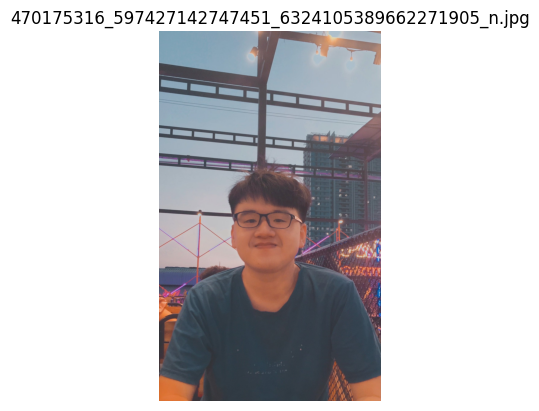

Ảnh: 470175316_597427142747451_6324105389662271905_n.jpg
  Age    : age_0 | probs = [9.8014498e-01 1.3298321e-03 2.0965644e-04 1.6603114e-03 1.6655298e-02]
  Gender : male | probs = [0.9621761  0.03782396]
  Race   : Black | probs = [0.16781764 0.78168666 0.02767901 0.00251925 0.02029749]
---------------------------------------------


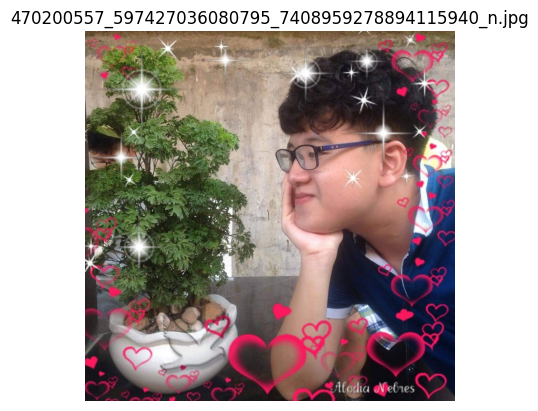

Ảnh: 470200557_597427036080795_7408959278894115940_n.jpg
  Age    : age_0 | probs = [9.9803156e-01 9.9994777e-06 3.2049743e-06 6.4167805e-05 1.8910585e-03]
  Gender : male | probs = [9.9961805e-01 3.8188888e-04]
  Race   : White | probs = [9.9922395e-01 1.3138709e-04 1.8586421e-04 7.8898065e-06 4.5095215e-04]
---------------------------------------------


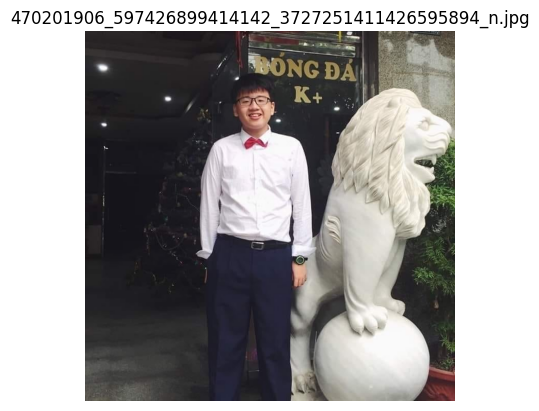

Ảnh: 470201906_597426899414142_3727251411426595894_n.jpg
  Age    : age_4 | probs = [8.7989174e-02 2.1980515e-05 4.3849675e-05 7.7918814e-03 9.0415305e-01]
  Gender : male | probs = [0.9939976  0.00600241]
  Race   : White | probs = [9.9972099e-01 5.3073112e-05 1.8827898e-04 4.2845336e-06 3.3345979e-05]
---------------------------------------------


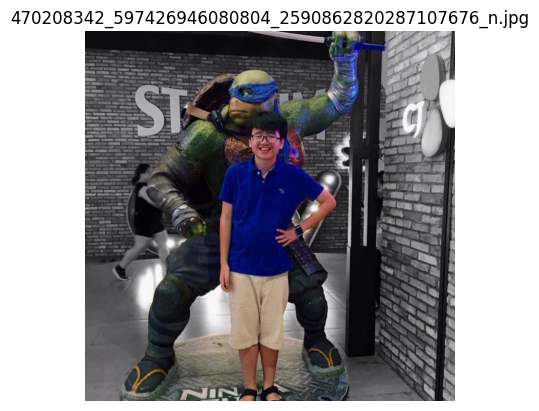

Ảnh: 470208342_597426946080804_2590862820287107676_n.jpg
  Age    : age_0 | probs = [0.62939847 0.00812614 0.00685295 0.0514285  0.3041939 ]
  Gender : male | probs = [0.8262082  0.17379187]
  Race   : Black | probs = [0.0658394  0.899224   0.01915526 0.00600338 0.00977795]
---------------------------------------------


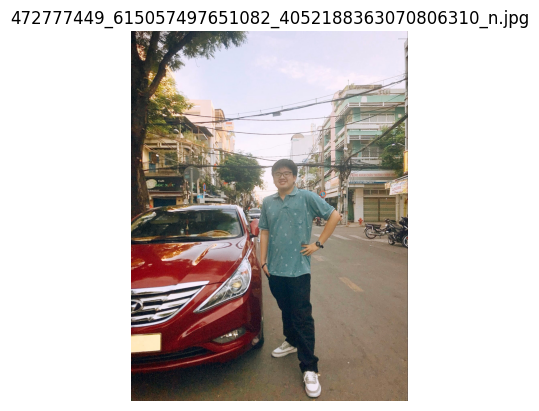

Ảnh: 472777449_615057497651082_4052188363070806310_n.jpg
  Age    : age_0 | probs = [6.7558891e-01 1.5834138e-03 6.4146210e-04 2.0615598e-02 3.0157056e-01]
  Gender : male | probs = [0.99806696 0.00193309]
  Race   : White | probs = [9.9815351e-01 4.8759632e-04 9.9492550e-04 4.4268465e-05 3.1976443e-04]
---------------------------------------------


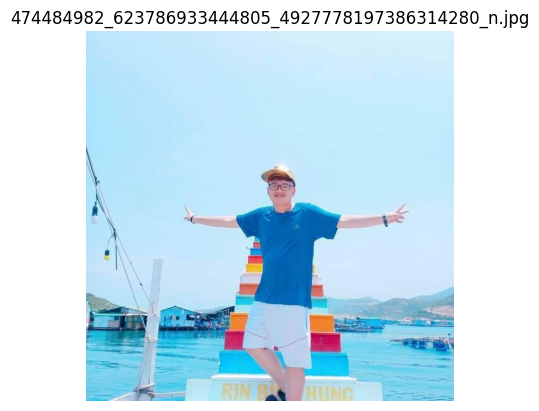

Ảnh: 474484982_623786933444805_4927778197386314280_n.jpg
  Age    : age_4 | probs = [3.8270587e-01 9.1188628e-04 5.1836087e-04 5.8770990e-03 6.0998678e-01]
  Gender : male | probs = [0.7898719  0.21012811]
  Race   : White | probs = [9.6020401e-01 1.4512209e-03 3.7157230e-02 4.6861515e-04 7.1895821e-04]
---------------------------------------------


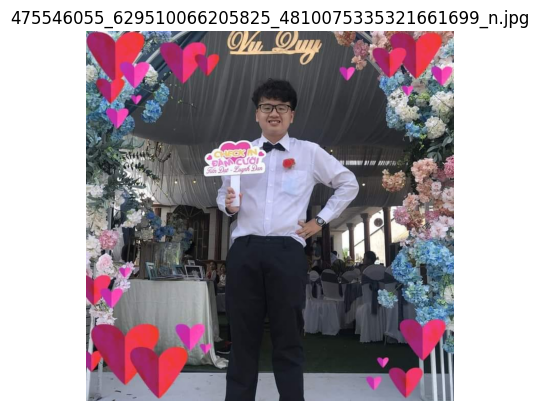

Ảnh: 475546055_629510066205825_4810075335321661699_n.jpg
  Age    : age_4 | probs = [1.0720654e-01 1.1569190e-04 1.1068674e-04 5.1964037e-03 8.8737071e-01]
  Gender : male | probs = [0.96421635 0.03578361]
  Race   : White | probs = [9.2816126e-01 5.6343088e-03 6.4499304e-02 8.1357150e-04 8.9156930e-04]
---------------------------------------------

✅ Hoàn thành dự đoán tất cả ảnh.


In [ ]:
import os
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

# class labels
age_classes = ["age_0", "age_1", "age_2", "age_3", "age_4"]
gender_classes = ["male", "female"]
race_classes = ["White", "Black", "Asian", "Indian", "Others"]

def predict_folder(folder_path, model, device, img_tfms):
    results = []

    valid_ext = (".jpg", ".jpeg", ".png", ".bmp")
    files = [f for f in sorted(os.listdir(folder_path)) if f.lower().endswith(valid_ext)]

    if len(files) == 0:
        print("⚠️ Không có file ảnh:", folder_path)
        return []

    print(f"🔍 Phát hiện {len(files)} ảnh, bắt đầu dự đoán...\n")

    for fname in files:
        img_path = os.path.join(folder_path, fname)

        # đọc ảnh
        img = Image.open(img_path).convert("RGB")
        x = img_tfms(img).unsqueeze(0).to(device)

        # dự đoán
        with torch.no_grad():
            age_logits, gender_logits, race_logits = model(x)

            age_prob    = F.softmax(age_logits, dim=1)[0]
            gender_prob = F.softmax(gender_logits, dim=1)[0]
            race_prob   = F.softmax(race_logits, dim=1)[0]

            age_idx    = age_prob.argmax().item()
            gender_idx = gender_prob.argmax().item()
            race_idx   = race_prob.argmax().item()

        # ==========================
        # HIỂN THỊ ẢNH
        # ==========================
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{fname}")
        plt.show()

        # In kết quả
        print("Ảnh:", fname)
        print("  Age    :", age_classes[age_idx],      "| probs =", age_prob.cpu().numpy())
        print("  Gender :", gender_classes[gender_idx], "| probs =", gender_prob.cpu().numpy())
        print("  Race   :", race_classes[race_idx],    "| probs =", race_prob.cpu().numpy())
        print("---------------------------------------------")

        # lưu vào list
        results.append({
            "image_path": img_path,
            "age_idx": age_idx,
            "gender_idx": gender_idx,
            "race_idx": race_idx,
            "age_prob": age_prob.cpu().numpy(),
            "gender_prob": gender_prob.cpu().numpy(),
            "race_prob": race_prob.cpu().numpy(),
        })

    print("\n✅ Hoàn thành dự đoán tất cả ảnh.")
    return results


# --- GỌI HÀM ---
folder_path = "/content/drive/MyDrive/Nhom1_Py/Dataset/sample_img"
results = predict_folder(folder_path, model, device, img_tfms)